## 在 Colab 上使用 GDINA

- 2026-03-13
- jw

[重要] 要先在 Edit/Notebook settings 中變更為 R.

用 apt 直接在 colab 雲端機器上安裝 r-cran-gdina 比用 r 安裝快。（但需要等待 apt 更新時間）

或者使用一般 r 的安裝套件方式。

```
install.package('GDINA')
```

In [ ]:
system('sudo apt upgrade')
system('sudo apt install r-cran-gdina')

1. 載入 GDINA 套件。
2. 使用範例 dat, 建立 Q-matrix.

In [ ]:
library(GDINA)
dat <- sim10GDINA$simdat
Q <- matrix(c(1,0,0,
              0,1,0,
              0,0,1,
              1,0,1,
              0,1,1,
              1,1,0,
              0,0,1,
              1,0,0,
              1,1,1,
              1,0,1),
              10,3)
Q

1,0,1
0,1,1
0,0,0
0,1,0
1,1,1
0,1,1
0,1,1
0,0,1
1,0,0
1,0,1


執行 GDINA 模式估計。

In [ ]:
est <- GDINA(dat = dat, Q = Q, model = "GDINA")

Iter = 74  Max. abs. change = 0.00010  Deviance  = 12137.15                                                                                  

In [ ]:
summary(est)


Test Fit Statistics

Loglik = -6068.57 

AIC    = 12219.15  | penalty [2 * p]  = 82.00 
AICc   = 12140.74  | penalty [2 * p * (p+1) / (n - p - 1)]  = 324.22 
BIC    = 12420.36  | penalty [log(n) * p]  = 283.22 
CAIC   = 12461.36  | penalty [(log(n) + 1) * p]  = 324.22 
SABIC  = 12290.15  | penalty [log((n + 2)/24) * p]  = 153.00 

No. of parameters (p)  = 41 
  No. of estimated item parameters =  34 
  No. of fixed item parameters =  0 
  No. of distribution parameters =  7 

Attribute Prevalence

   Level0 Level1
A1 0.4148 0.5852
A2 0.4735 0.5265
A3 0.4920 0.5080

In [ ]:
coef(est)

$`Item 1`
  P(0)   P(1) 
0.1582 0.8278 

$`Item 2`
  P(0)   P(1) 
0.1216 0.7664 

$`Item 3`
  P(0)   P(1) 
0.1109 0.9103 

$`Item 4`
 P(00)  P(10)  P(01)  P(11) 
0.1319 0.2597 0.4882 0.8374 

$`Item 5`
 P(00)  P(10)  P(01)  P(11) 
0.1136 0.0654 0.0675 0.7980 

$`Item 6`
 P(00)  P(10)  P(01)  P(11) 
0.1736 0.8834 0.9331 0.9069 

$`Item 7`
  P(0)   P(1) 
0.2597 0.5910 

$`Item 8`
  P(0)   P(1) 
0.1297 0.5643 

$`Item 9`
P(000) P(100) P(010) P(001) P(110) P(101) P(011) P(111) 
0.1384 0.0511 0.5329 0.3725 0.3092 0.4261 0.7841 0.8126 

$`Item 10`
 P(00)  P(10)  P(01)  P(11) 
0.1716 0.3439 0.5148 0.7011

畫出每個題目在不同屬性上的成功機率。

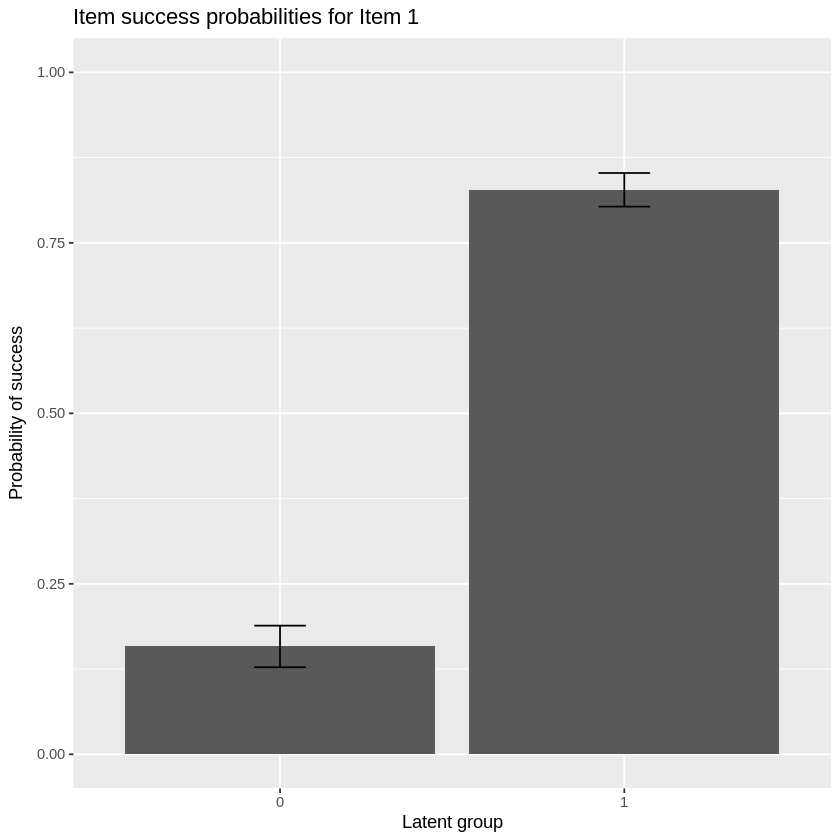

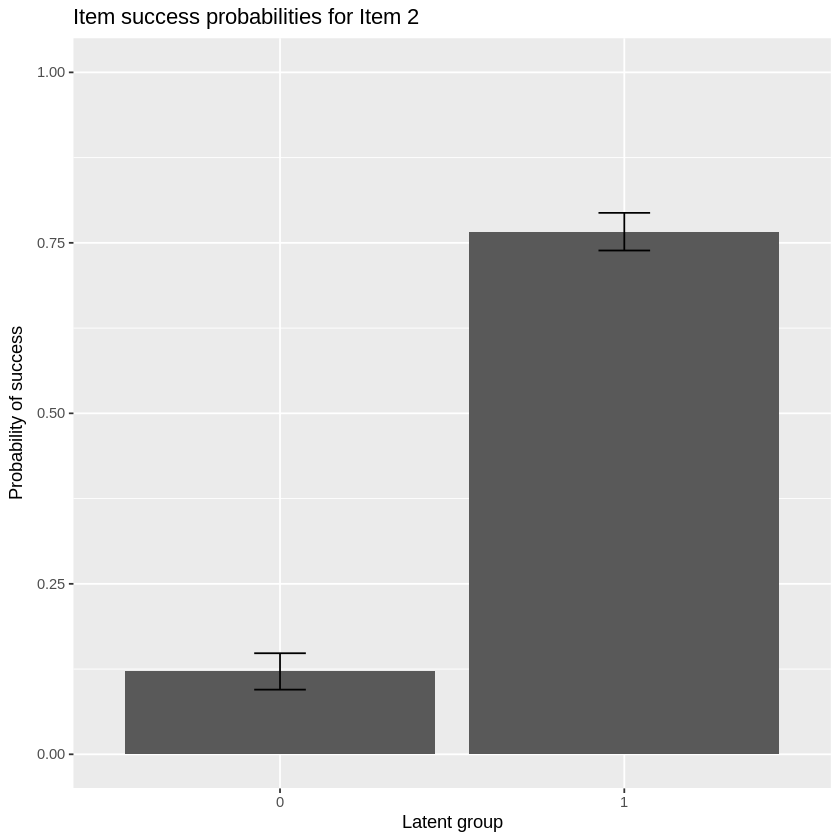

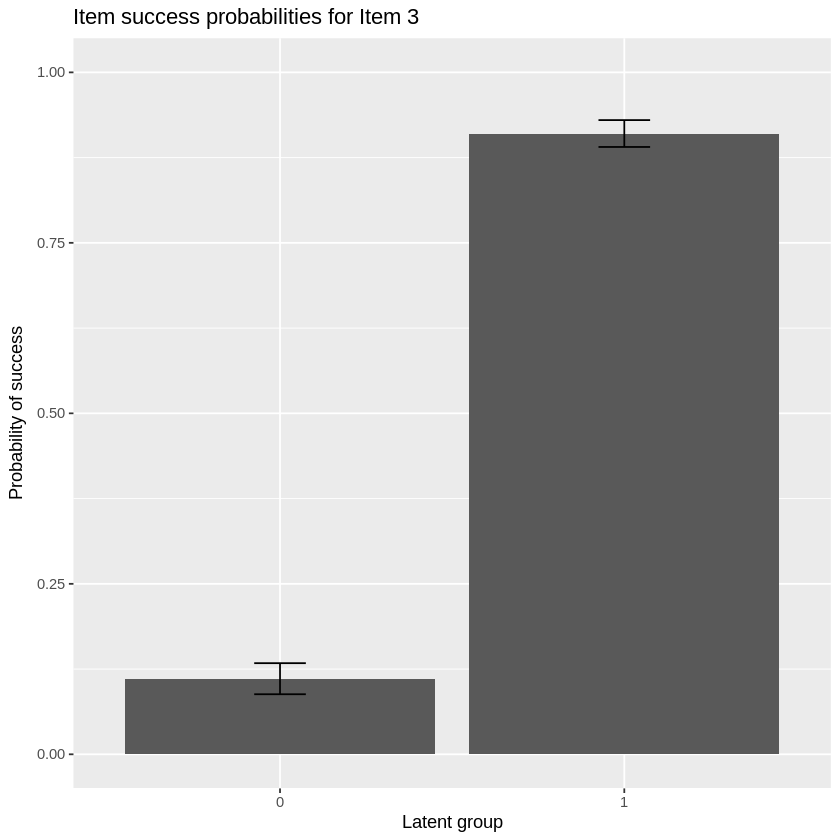

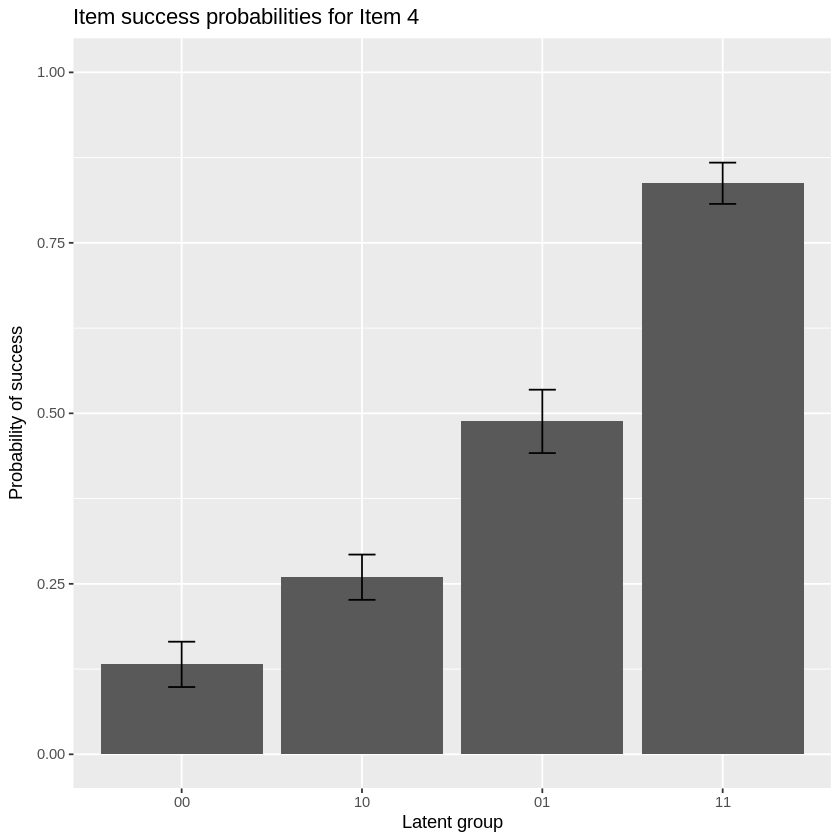

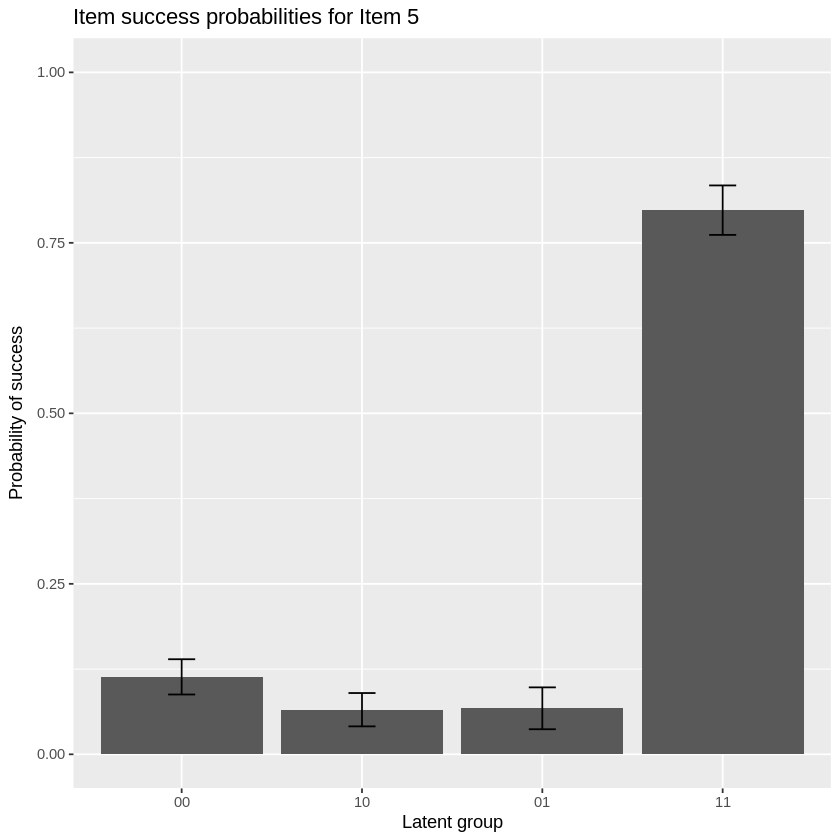

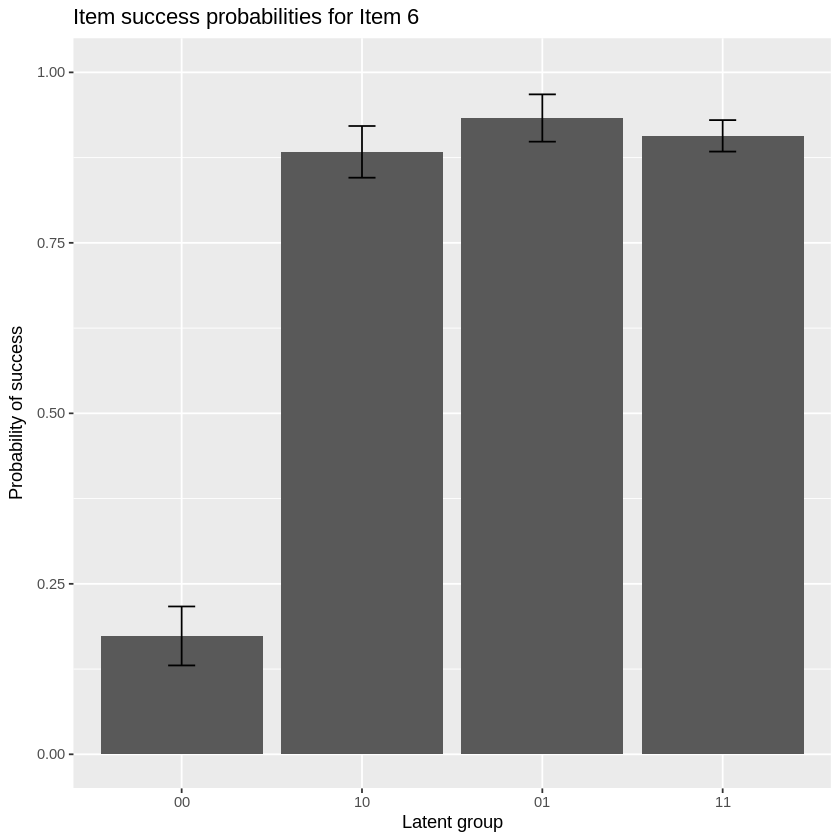

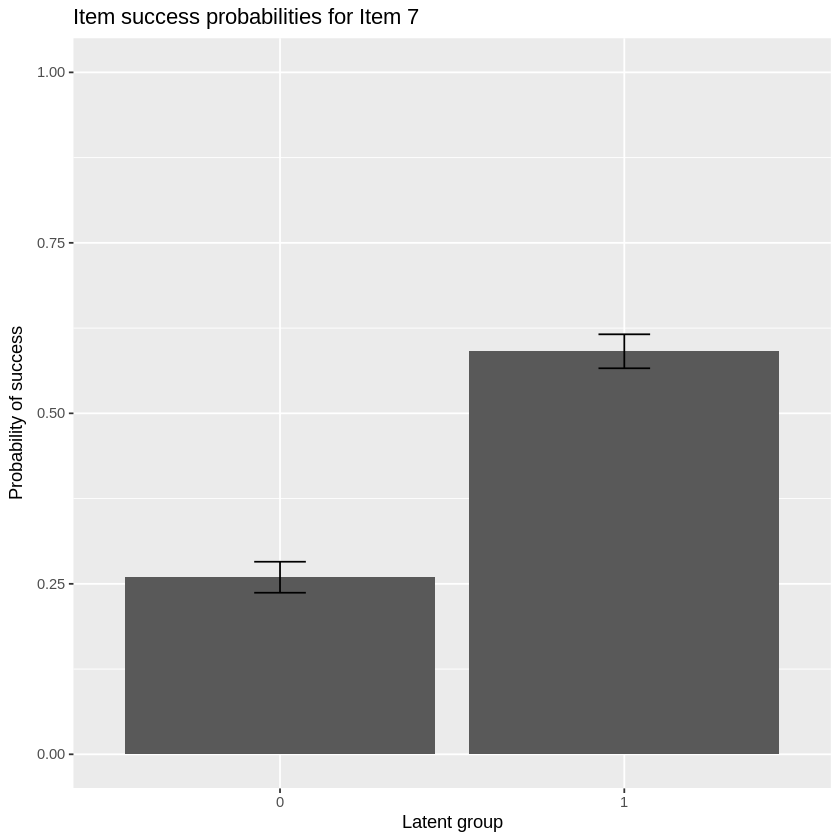

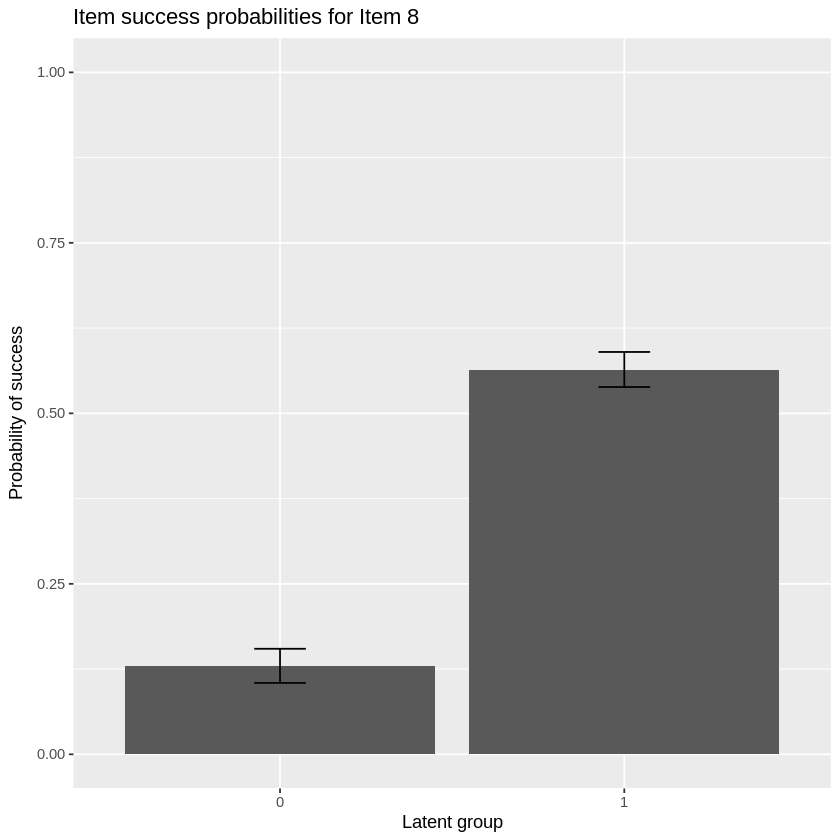

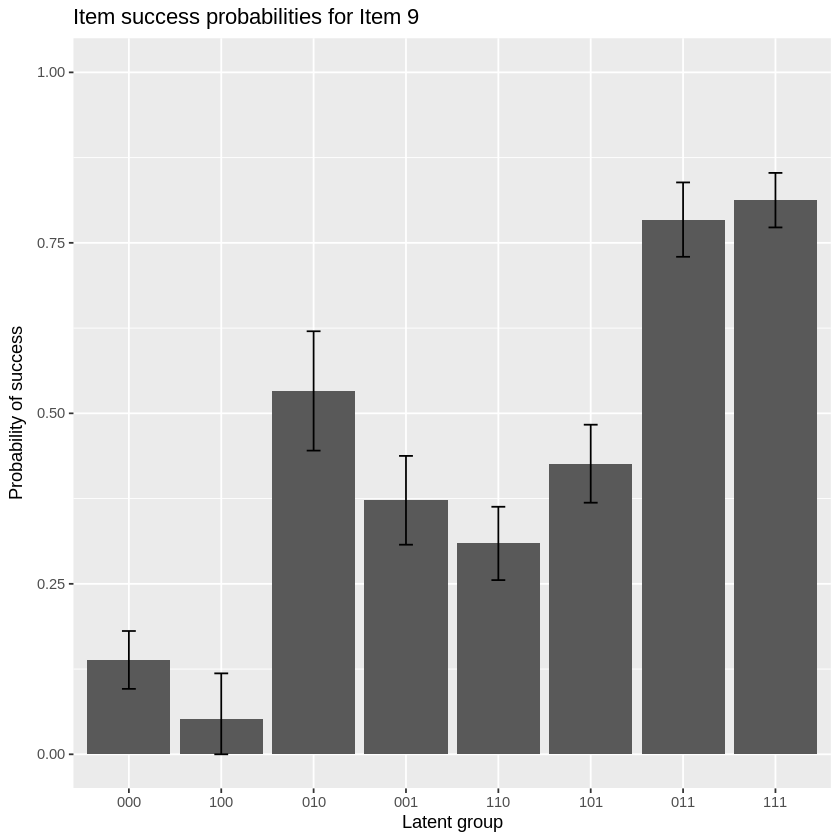

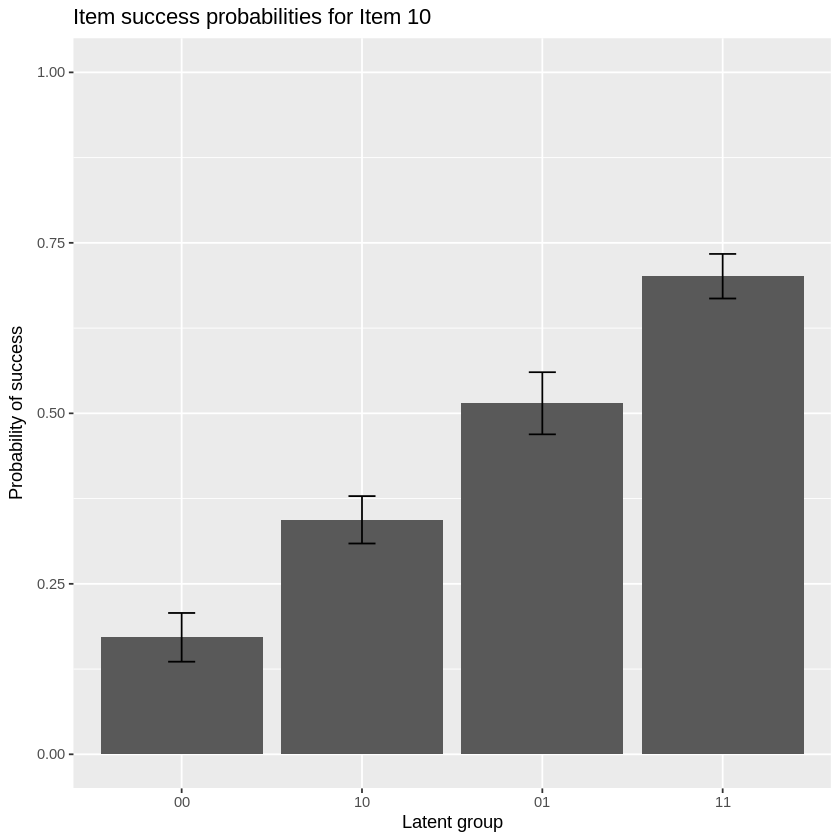

In [ ]:
plot(est, withSE = TRUE)

畫出第 1, 20, 50 個人在三個屬性上的精熟程度

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the GDINA package.
  Please report the issue at <https://github.com/Wenchao-Ma/GDINA/issues>.”


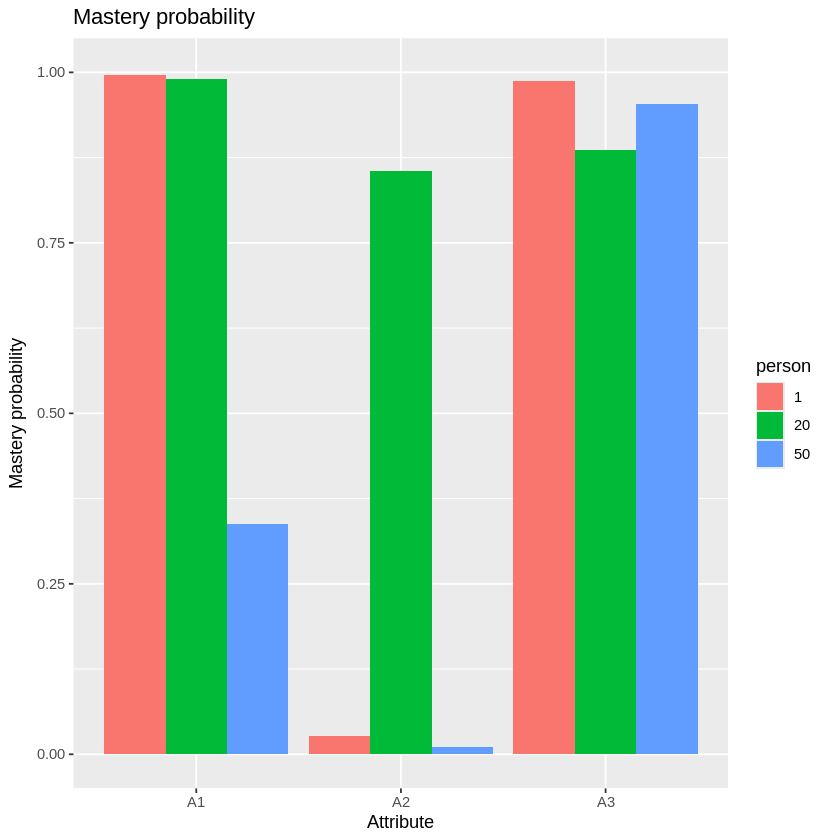

In [ ]:
#plot mastery probability for individuals 1, 20 and 50
plot(est, what = "mp", person = c(1, 20, 50))

分類準確率

In [ ]:
CA(est)

Classification Accuracy 

Test level accuracy =  0.738 

Pattern level accuracy: 

   000    100    010    001    110    101    011    111 
0.7787 0.6716 0.6358 0.7300 0.7022 0.7574 0.7843 0.7875 

Attribute level accuracy: 

    A1     A2     A3 
0.8822 0.8831 0.9252 

Q-matrix 驗證. 有星號表示 Q-matrix 建議修改的位置。

In [ ]:
Qv <- Qval(est)
Qv


Q-matrix validation based on PVAF method 

Suggested Q-matrix: 

   A1 A2 A3
1  1  0  0 
2  0  1  0 
3  0  0  1 
4  1  0  1 
5  0  1  1 
6  1  1  0 
7  1* 0  1 
8  1  1* 0 
9  0* 1  1 
10 1  1* 1 
Note: * denotes a modified element.

In [ ]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] GDINA_2.9.12  lavaan_0.6-10

loaded via a namespace (and not attached):
 [1] future_1.69.0        listenv_0.10.1       digest_0.6.39       
 [4] magrittr_2.0.4       RColorBre